> Dated : 13/06/2026

# Machine Learning 
#### Ratnakar Pandey

In [6]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
# Interactive Shell import to print many statements on the same line.
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

In [24]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [25]:
housing.keys()
housing.data.shape
housing.feature_names
housing.target

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

(20640, 8)

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [13]:
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [17]:
housing_df['HouseAge']
housing.target

housing_df.head()
housing_df.describe()

0        41.0
1        21.0
2        52.0
3        52.0
4        52.0
         ... 
20635    25.0
20636    18.0
20637    17.0
20638    18.0
20639    16.0
Name: HouseAge, Length: 20640, dtype: float64

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [26]:
x = housing_df.corr()
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


(<Figure size 2000x2000 with 1 Axes>, <Axes: >)

<Axes: >

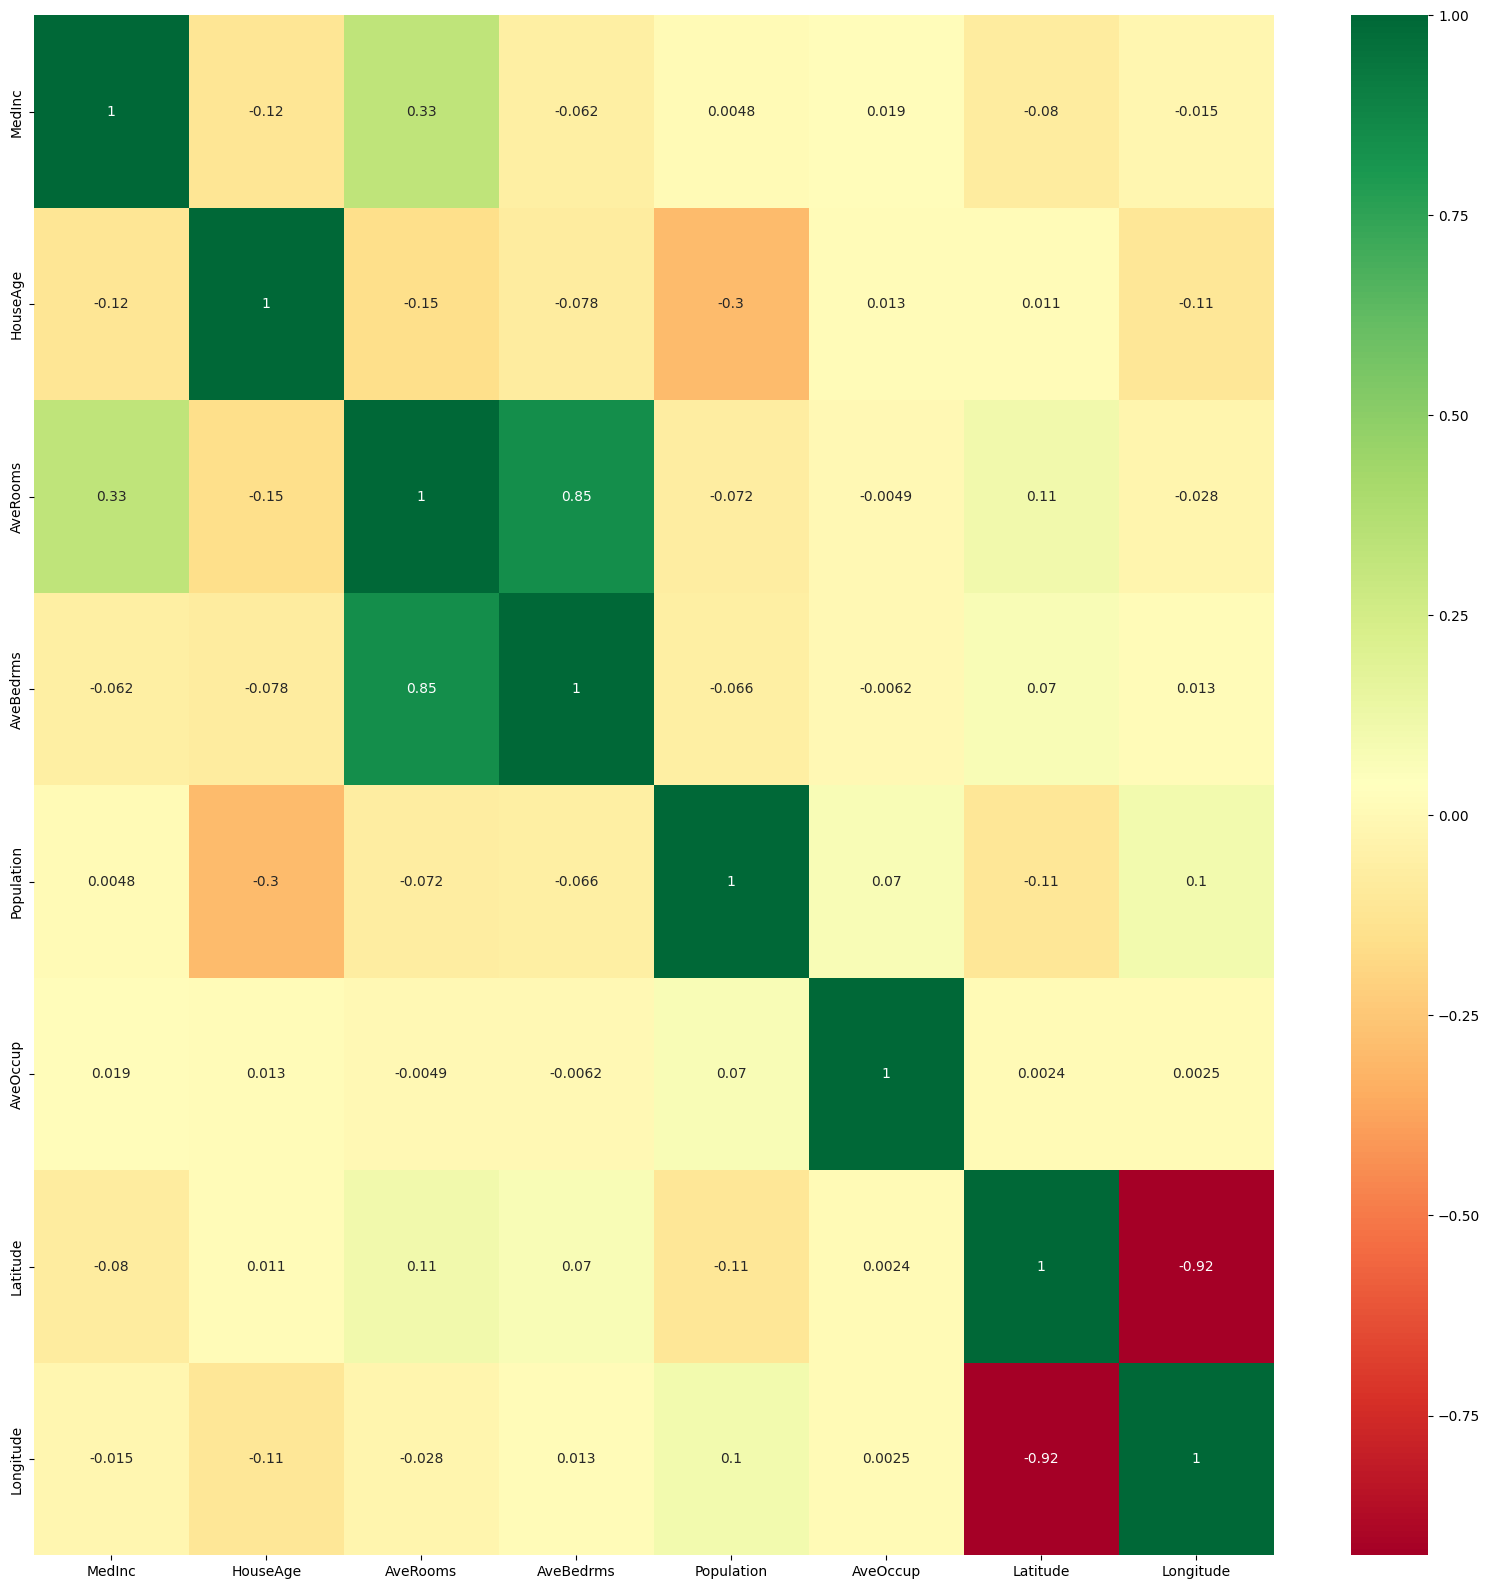

In [27]:
plt.subplots(figsize=(20,20))
sns.heatmap(x, cmap = 'RdYlGn', annot= True)
plt.show()


In [28]:
x = housing_df.drop('HouseAge', axis = 1)
y = housing_df['HouseAge']
x.head()
y.head()

,MedInc,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,6.281853,1.081081,565.0,2.181467,37.85,-122.25


0    41.0
1    21.0
2    52.0
3    52.0
4    52.0
Name: HouseAge, dtype: float64

In [29]:
train_x, test_x, train_y, test_y = train_test_split (x,y, test_size=0.25, random_state=1)
train_x.shape

test_x.shape
train_y.shape
test_y. shape

(15480, 7)

(5160, 7)

(15480,)

(5160,)

In [30]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
lm.fit(train_x, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
predict_test = lm.predict(test_x)

In [33]:
print(lm.coef_)
df_m = pd.DataFrame({'features': x.columns, 'coeff':lm.coef_})
df_m = df_m.sort_values(by=['coeff'])

df_m

[-9.87362768e-01 -6.16730186e-01  1.60267307e+00 -3.44025020e-03
  4.86367696e-02 -4.19526147e+00 -4.65136126e+00]


,features,coeff
6,Longitude,-4.651361
5,Latitude,-4.195261
0,MedInc,-0.987363
1,AveRooms,-0.616730
3,Population,-0.003440
4,AveOccup,0.048637
2,AveBedrms,1.602673


<Axes: xlabel='features'>

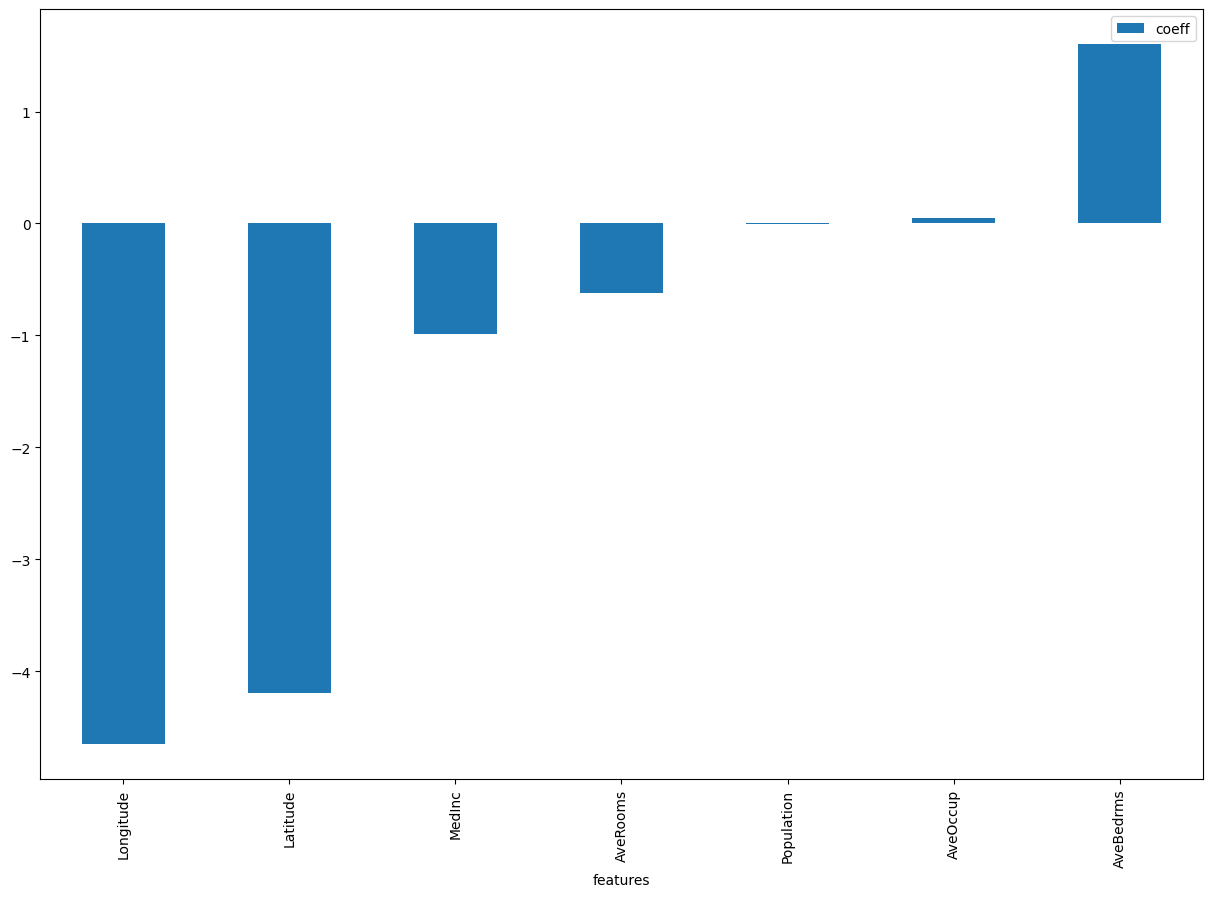

In [34]:
df_m.plot(x='features', y = 'coeff', kind = 'bar', figsize=(15,10))
plt.show()

In [36]:
print(f"RSquare TEST: {np.round(lm.score(test_x, test_y) * 100, 0)}%")
print(f"RSquare TRAIN: {np.round(lm.score(train_x, train_y) * 100, 0)}%")

RSquare TEST: 19.0%
RSquare TRAIN: 20.0%


Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127  ...     37.88    -122.23        4.526
1  8.3014      21.0  6.238137  ...     37.86    -122.22        3.585
2  7.2574      52.0  8.288136  ...     37.85    -122.24        3.521
3  5.6431      52.0  5.817352  ...     37.85    -122.25        3.413
4  3.8462      52.0  6.281853  ...     37.85    -122.25        3.422

[5 rows x 9 columns]
             MedInc      HouseAge  ...     Longitude   MedHouseVal
count  20640.000000  20640.000000  ...  20640.000000  20640.000000
mean       3.870671     28.639486  ...   -119.569704      2.068558
std        1.899822     12.585558  ...      2.003532      1.153956
min        0.499900      1.000000  ...   -124.350000      0.149990
25%        2.563400     18.000000  ...   -121.800000      1.196000
50%        3.534800     29.000000  ...   -118.490000      1.797000
75%        4.743250     37.000000  ...   -118.010000      2.647250
max       

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap')

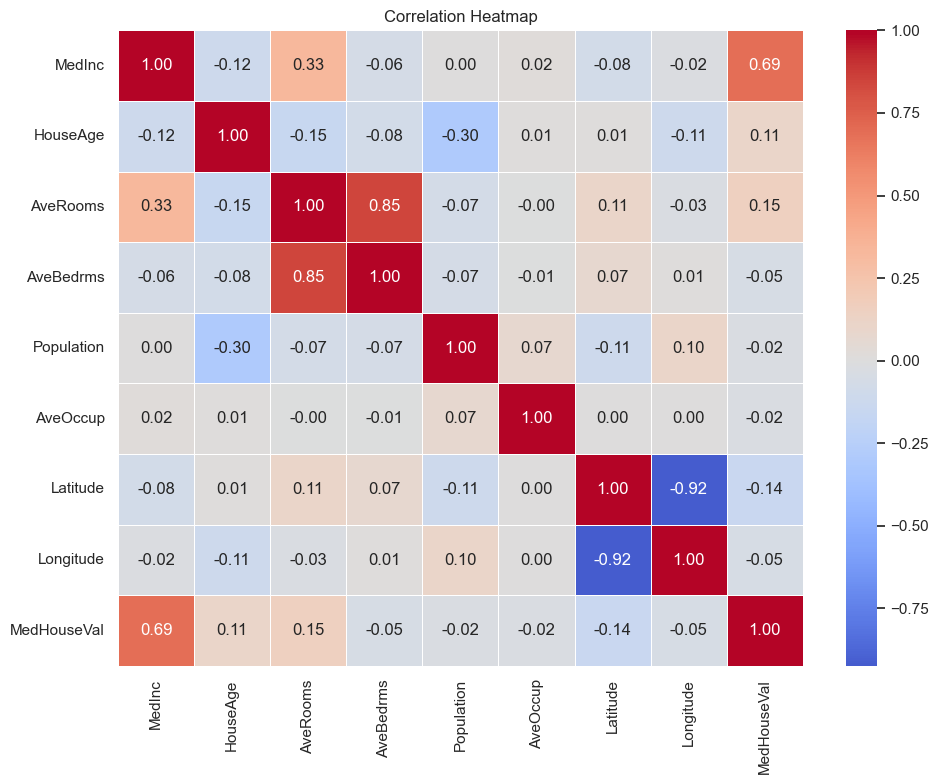

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



Intercept: 2.0679
      Feature  Coefficient
6    Latitude    -0.896635
7   Longitude    -0.868927
0      MedInc     0.852382
3   AveBedrms     0.371132
2    AveRooms    -0.305116
1    HouseAge     0.122382
5    AveOccup    -0.036624
4  Population    -0.002298


<Figure size 900x500 with 0 Axes>

<Axes: xlabel='Feature'>

Text(0.5, 1.0, 'Feature Coefficients')

Text(0, 0.5, 'Coefficient')

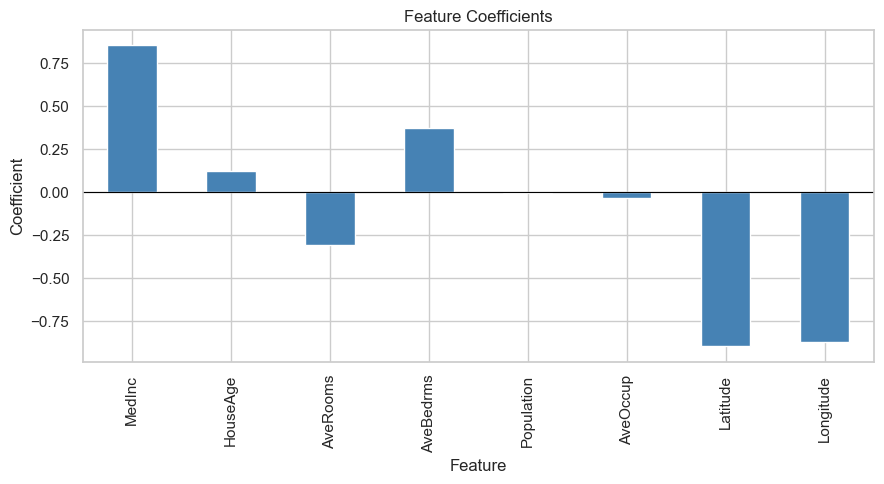


R²   : 0.5758
MSE  : 0.5559
RMSE : 0.7456
MAE  : 0.5332

Sample results:
    Actual  Predicted   Error  Abs_Error
0   0.477     0.7191 -0.2421     0.2421
1   0.458     1.7640 -1.3060     1.3060
2   5.000     2.7097  2.2904     2.2904
3   2.186     2.8389 -0.6529     0.6529
4   2.780     2.6047  0.1753     0.1753
5   1.587     2.0118 -0.4248     0.4248
6   1.982     2.6455 -0.6635     0.6635
7   1.575     2.1688 -0.5938     0.5938
8   3.400     2.7407  0.6593     0.6593
9   4.466     3.9156  0.5504     0.5504

Error summary:
            Error  Abs_Error
count  4128.0000  4128.0000
mean      0.0035     0.5332
std       0.7457     0.5212
min      -9.8753     0.0001
25%      -0.4609     0.1968
50%      -0.1224     0.4102
75%       0.3124     0.6886
max       4.1484     9.8753


<Figure size 700x600 with 0 Axes>

Text(0.5, 0, 'Actual ($100k)')

Text(0, 0.5, 'Predicted ($100k)')

Text(0.5, 1.0, 'Actual vs Predicted (R² = 0.576)')

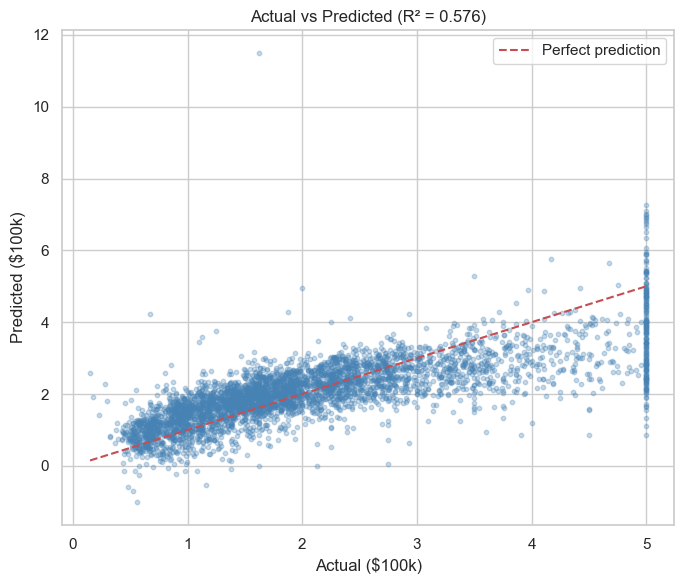

<Axes: xlabel='Error', ylabel='Count'>

Text(0.5, 1.0, 'Residual Distribution')

Text(0.5, 0, 'Actual − Predicted')

<Axes: xlabel='Abs_Error', ylabel='Count'>

Text(0.5, 1.0, 'Absolute Error Distribution')

Text(0.5, 0, '|Actual − Predicted|')

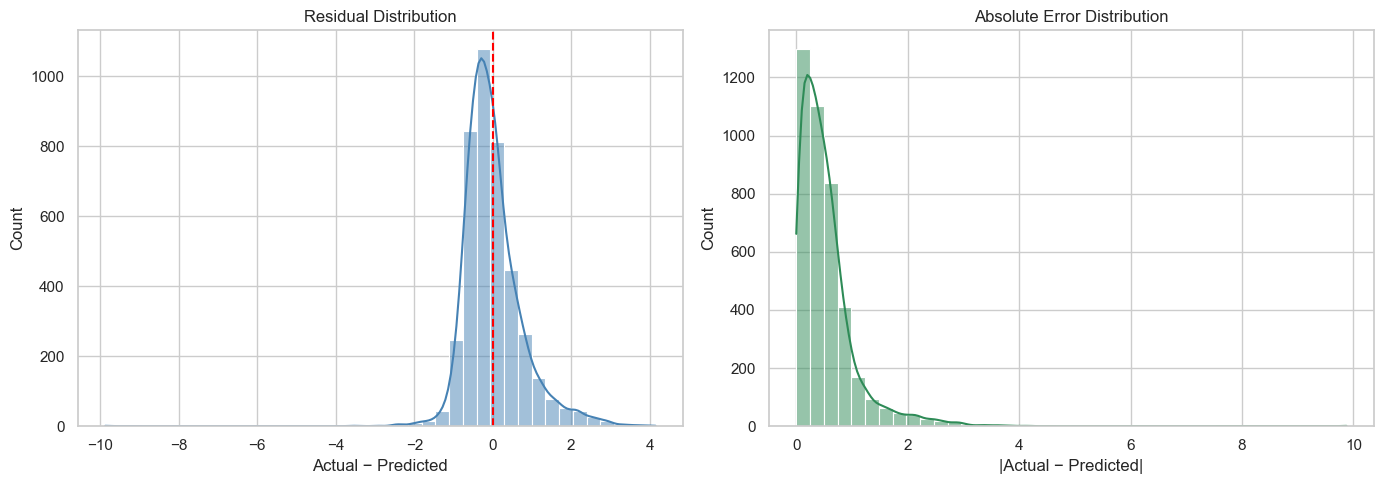

Text(0.5, 0, 'Predicted ($100k)')

Text(0, 0.5, 'Residual')

Text(0.5, 1.0, 'Residuals vs Fitted')

((array([-3.58599225, -3.34761805, -3.21608001, ...,  3.21608001,
          3.34761805,  3.58599225], shape=(4128,)),
  array([-9.87533103, -3.56121467, -2.94613738, ...,  3.68005569,
          3.88478255,  4.1483882 ], shape=(4128,))),
 (np.float64(0.7081530258158821),
  np.float64(0.0034792979037500424),
  np.float64(0.9490579102595861)))

Text(0.5, 1.0, 'Q-Q Plot')

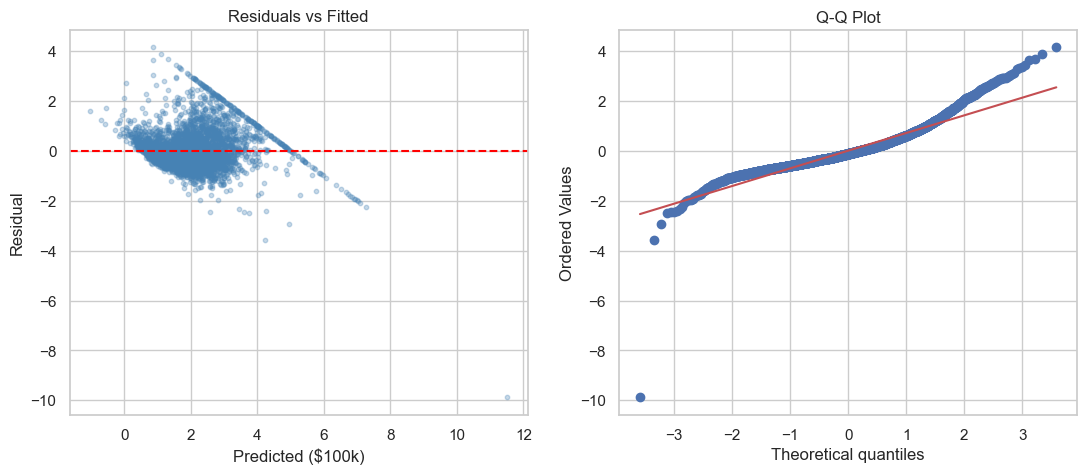

In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


# --- Load data & EDA ---
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target
print("Shape:", df.shape)
print(df.head())
print(df.describe())
print("Missing values:\n", df.isnull().sum())
corr = df.corr()
print("\nCorrelation matrix:\n", corr.round(3))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# --- STEP 1: features & label ---
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]


# --- STEP 2: scale ---
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)


# --- STEP 3: train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- STEP 4 & 5: instantiate & fit ---
model = LinearRegression()
model.fit(X_train, y_train)
print(f"\nIntercept: {model.intercept_:.4f}")
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print(coef_df.sort_values("Coefficient", key=abs, ascending=False))
plt.figure(figsize=(9, 5))
coef_df.set_index("Feature")["Coefficient"].plot(kind="bar", color="steelblue")
plt.title("Feature Coefficients")
plt.ylabel("Coefficient")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


# --- STEP 6: predict & evaluate ---
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nR²   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {np.sqrt(mse):.4f}")
print(f"MAE  : {mae:.4f}")
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
})
results["Error"] = results["Actual"] - results["Predicted"]
results["Abs_Error"] = results["Error"].abs()
print("\nSample results:\n", results.head(10).round(4))
print("\nError summary:\n", results[["Error", "Abs_Error"]].describe().round(4))
residuals = results["Error"]
abs_errors = results["Abs_Error"]
# Actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(results["Actual"], results["Predicted"], alpha=0.3, s=10, color="steelblue")
lims = [results["Actual"].min(), results["Actual"].max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual ($100k)")
plt.ylabel("Predicted ($100k)")
plt.title(f"Actual vs Predicted (R² = {r2:.3f})")
plt.legend()
plt.tight_layout()
plt.show()


# Error distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Actual − Predicted")
sns.histplot(abs_errors, bins=40, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Absolute Error Distribution")
axes[1].set_xlabel("|Actual − Predicted|")
plt.tight_layout()
plt.show()


# Residuals vs fitted & Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(results["Predicted"], residuals, alpha=0.3, s=10, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted ($100k)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted")
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.show()
